# Mercer Kernels

## Real-World Scenario: Cell Phenotype Similarity from Gene Expression

In whole cell modeling, we measure **gene expression profiles** across thousands of cells and want to predict **cellular phenotypes** (e.g., growth rate, metabolic flux, stress response). The key insight behind kernel methods is simple: if two cells have *similar* expression profiles, they should have *similar* phenotypes.

A **Mercer kernel** $\kappa(\mathbf{x}, \mathbf{x}')$ formalizes this notion of similarity. It assigns a non-negative score to any pair of inputs, and the resulting **Gram matrix** is guaranteed to be positive semi-definite — which unlocks powerful algorithms like Gaussian processes and SVMs.

We explore:

1. **Mercer kernel definition** and the positive-definiteness condition
2. **The Gram matrix** — visualizing pairwise cell similarity
3. **Mercer's theorem** — the implicit feature map (kernel trick)
4. **Popular kernels**: RBF, Matern, periodic, polynomial
5. **ARD kernel** — automatic relevance determination for gene selection
6. **Combining kernels** — addition and multiplication to capture complex structure

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.special import kv as bessel_kv, gamma as gamma_fn

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 17.1

**Mercer kernel** (positive definite kernel) — a symmetric function $\kappa : \mathcal{X} \times \mathcal{X} \to \mathbb{R}_+$ satisfying (Eq. 17.1):

$$\sum_{i=1}^{N} \sum_{j=1}^{N} \kappa(\mathbf{x}_i, \mathbf{x}_j)\, c_i\, c_j \geq 0 \qquad \forall\; \{c_i\} \in \mathbb{R},\; \{\mathbf{x}_i\} \in \mathcal{X}$$

**Gram matrix** (Eq. 17.2):

$$\mathbf{K} = \begin{pmatrix} \kappa(\mathbf{x}_1, \mathbf{x}_1) & \cdots & \kappa(\mathbf{x}_1, \mathbf{x}_N) \\ \vdots & & \vdots \\ \kappa(\mathbf{x}_N, \mathbf{x}_1) & \cdots & \kappa(\mathbf{x}_N, \mathbf{x}_N) \end{pmatrix}$$

$\kappa$ is Mercer iff $\mathbf{K} \succeq 0$ for any set of distinct inputs.

**RBF / Squared Exponential kernel** (Eq. 17.3):

$$\kappa(\mathbf{x}, \mathbf{x}') = \exp\!\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

**Mercer's theorem** — feature map representation (Eq. 17.5):

$$\kappa(\mathbf{x}_i, \mathbf{x}_j) = \boldsymbol{\phi}(\mathbf{x}_i)^\top \boldsymbol{\phi}(\mathbf{x}_j) = \sum_m \phi_m(\mathbf{x}_i)\,\phi_m(\mathbf{x}_j)$$

**ARD kernel** (Eq. 17.8):

$$\kappa(\mathbf{x}, \mathbf{x}') = \sigma^2 \exp\!\left(-\frac{1}{2} \sum_{d=1}^{D} \frac{(x_d - x_d')^2}{\ell_d^2}\right)$$

**Matern kernel** (Eq. 17.10–17.13), e.g. $\nu = 5/2$:

$$\kappa(r;\, \tfrac{5}{2},\, \ell) = \left(1 + \frac{\sqrt{5}\,r}{\ell} + \frac{5\,r^2}{3\,\ell^2}\right) \exp\!\left(-\frac{\sqrt{5}\,r}{\ell}\right)$$

**Periodic kernel** (Eq. 17.14):

$$\kappa(r;\, \ell,\, p) = \exp\!\left(-\frac{2}{\ell^2} \sin^2\!\left(\frac{\pi r}{p}\right)\right)$$

**Kernel combination rules** (Eq. 17.25–17.26): addition gives *disjunction* of properties, multiplication gives *conjunction*.

## 1. Generate Synthetic Cell Gene Expression Data

We simulate gene expression profiles for 60 cells across 6 genes involved in different metabolic pathways. Cells come from 3 phenotypic groups: **high growth**, **stress response**, and **quiescent**. Only genes 0–2 are truly discriminative; genes 3–5 are noisy housekeeping genes.

In [2]:
N_per = 20
C = 3
D = 6
N = N_per * C

phenotype_names = ['High Growth', 'Stress Response', 'Quiescent']
gene_names = ['GrowthF', 'StressK', 'CyclinD', 'GAPDH', 'Actin', 'Tubulin']
colors = ['#2ca02c', '#d62728', '#1f77b4']

# Class centers: only dims 0-2 discriminative
centers = np.array([
    [ 3.0,  0.5,  2.5,  0.0,  0.0,  0.0],   # High growth
    [ 0.5,  3.0, -1.0,  0.0,  0.0,  0.0],   # Stress response
    [-1.5, -1.0, -1.5,  0.0,  0.0,  0.0],   # Quiescent
])

cov = np.diag([0.8, 0.8, 0.8, 3.0, 3.0, 3.0])

X, y = [], []
for c in range(C):
    X.append(np.random.multivariate_normal(centers[c], cov, N_per))
    y.append(np.full(N_per, c))
X = np.vstack(X)
y = np.concatenate(y)

# Shuffle
perm = np.random.permutation(N)
X, y = X[perm], y[perm]

print(f'Data shape: {X.shape}  (N={N} cells, D={D} genes)')
print(f'Classes: {dict(zip(phenotype_names, [np.sum(y==c) for c in range(C)]))}')

Data shape: (60, 6)  (N=60 cells, D=6 genes)
Classes: {'High Growth': 20, 'Stress Response': 20, 'Quiescent': 20}


## 2. Mercer Kernel Definition and the Gram Matrix

A function $\kappa(\mathbf{x}, \mathbf{x}')$ is a **Mercer kernel** if the Gram matrix $\mathbf{K}$ it produces is positive semi-definite for *any* set of inputs. This means all eigenvalues of $\mathbf{K}$ are non-negative, and the quadratic form $\mathbf{c}^\top \mathbf{K} \mathbf{c} \geq 0$ for all $\mathbf{c}$.

The **RBF kernel** (Eq. 17.3) is the most widely used Mercer kernel:

$$\kappa(\mathbf{x}, \mathbf{x}') = \exp\!\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

The bandwidth $\ell$ controls the length scale: small $\ell$ means only very nearby points are considered similar.

/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_9472/460713210.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


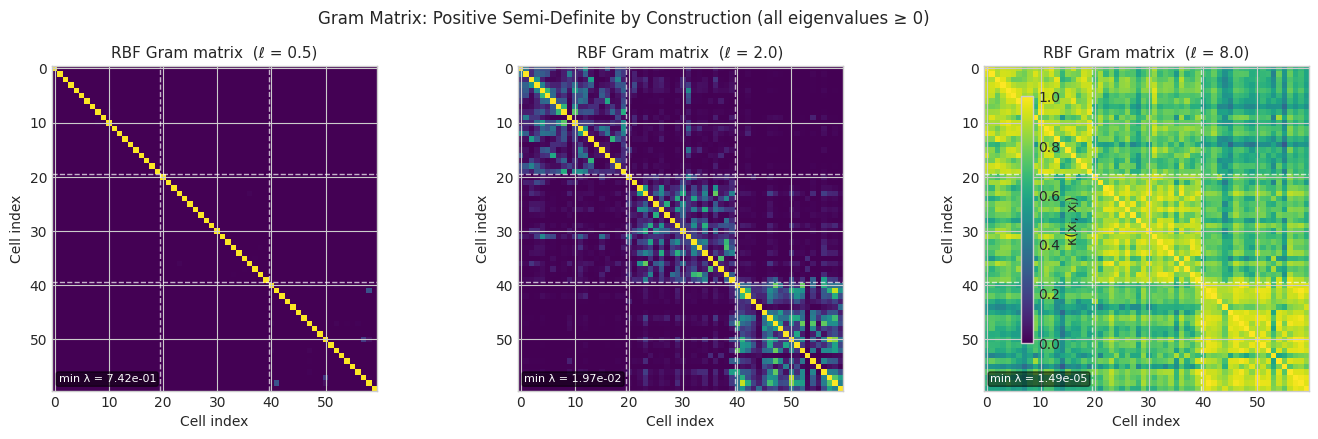

In [3]:
def rbf_kernel(X1, X2, length_scale=1.0):
    """RBF / Squared Exponential kernel (Eq. 17.3)."""
    sq_dists = cdist(X1, X2, metric='sqeuclidean')
    return np.exp(-sq_dists / (2 * length_scale**2))


# Sort cells by phenotype for cleaner visualization
sort_idx = np.argsort(y)
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]

# Compute Gram matrices at different length scales
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
length_scales = [0.5, 2.0, 8.0]

for ax, ell in zip(axes, length_scales):
    K = rbf_kernel(X_sorted, X_sorted, length_scale=ell)
    im = ax.imshow(K, cmap='viridis', vmin=0, vmax=1, aspect='equal')
    ax.set_title(f'RBF Gram matrix  (ℓ = {ell})', fontsize=11)
    ax.set_xlabel('Cell index')
    ax.set_ylabel('Cell index')

    # Mark phenotype boundaries
    for b in [N_per, 2 * N_per]:
        ax.axhline(b - 0.5, color='white', lw=1, ls='--', alpha=0.7)
        ax.axvline(b - 0.5, color='white', lw=1, ls='--', alpha=0.7)

    eigvals = np.linalg.eigvalsh(K)
    ax.text(0.02, 0.02, f'min λ = {eigvals.min():.2e}',
            transform=ax.transAxes, fontsize=8, color='white',
            va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

plt.colorbar(im, ax=axes, shrink=0.8, label='κ(xᵢ, xⱼ)')
plt.suptitle('Gram Matrix: Positive Semi-Definite by Construction (all eigenvalues ≥ 0)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation**: With small $\ell$, only near-identical cells get high similarity (sharp block structure). With large $\ell$, even distant cells appear similar (matrix approaches all-ones). The **block-diagonal** pattern shows that cells within the same phenotype are more similar — exactly what we want a kernel to capture.

The positive semi-definiteness check confirms all eigenvalues $\geq 0$, verifying this is a valid Mercer kernel.

## 3. Mercer's Theorem: The Kernel Trick

Mercer's theorem (Eq. 17.5) states that any Mercer kernel can be written as an inner product in some (possibly infinite-dimensional) feature space:

$$\kappa(\mathbf{x}, \mathbf{x}') = \boldsymbol{\phi}(\mathbf{x})^\top \boldsymbol{\phi}(\mathbf{x}')$$

This is the **kernel trick**: we never need to compute $\boldsymbol{\phi}$ explicitly — we just evaluate $\kappa$. But for finite kernels like the **polynomial kernel** $\kappa(\mathbf{x}, \mathbf{x}') = (\mathbf{x}^\top \mathbf{x}' + c)^M$, we can write down $\boldsymbol{\phi}$ explicitly.

For the quadratic kernel in 2D (Eq. 17.6): $\kappa(\mathbf{x}, \mathbf{x}') = (\mathbf{x}^\top \mathbf{x}')^2$ with $\boldsymbol{\phi}(x_1, x_2) = [x_1^2,\; \sqrt{2}\,x_1 x_2,\; x_2^2]$.

In [4]:
# Demonstrate the kernel trick with the quadratic kernel in 2D
# phi(x1, x2) = [x1^2, sqrt(2)*x1*x2, x2^2]
# Then phi(x)^T phi(x') = (x^T x')^2

# Use first two gene dimensions of a few cells
X_2d = X[:8, :2]

# Method 1: compute kernel directly
K_direct = (X_2d @ X_2d.T) ** 2

# Method 2: explicit feature map then inner product
def phi_quadratic(X):
    """Explicit feature map for quadratic kernel in 2D."""
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([x1**2, np.sqrt(2) * x1 * x2, x2**2])

Phi = phi_quadratic(X_2d)
K_feature = Phi @ Phi.T

# Verify they match
print('Quadratic kernel — direct vs. feature map:')
print(f'  Max absolute difference: {np.max(np.abs(K_direct - K_feature)):.2e}')
print(f'  Match: {np.allclose(K_direct, K_feature)}')
print(f'\n  Input dim:   {X_2d.shape[1]}')
print(f'  Feature dim: {Phi.shape[1]}  (maps 2D → 3D)')
print(f'\n  K (direct) first 4×4:\n{K_direct[:4,:4].round(2)}')

# For the RBF kernel, the feature space is infinite-dimensional
# We can approximate it using Random Fourier Features (Rahimi & Recht, 2007)
# but the kernel trick lets us skip this entirely

Quadratic kernel — direct vs. feature map:
  Max absolute difference: 1.42e-14
  Match: True

  Input dim:   2
  Feature dim: 3  (maps 2D → 3D)

  K (direct) first 4×4:
[[ 48.14  45.81  32.46  70.59]
 [ 45.81 130.74  22.19  36.4 ]
 [ 32.46  22.19  23.29  52.97]
 [ 70.59  36.4   52.97 124.15]]


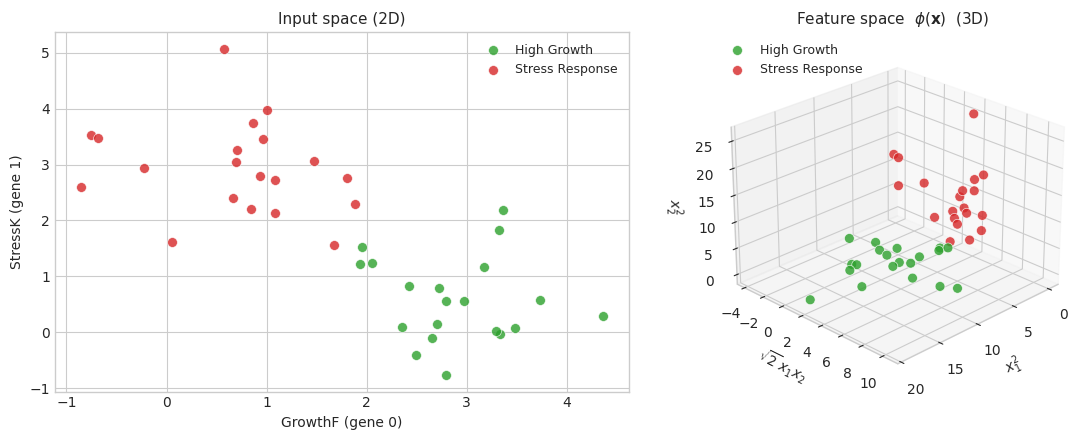

In [5]:
# Visualize: the quadratic feature map separates data that is not linearly separable in 2D
# Use cells from the first two phenotype classes
mask = y < 2
X_demo = X[mask, :2]
y_demo = y[mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Original 2D space
ax = axes[0]
for c in range(2):
    m = y_demo == c
    ax.scatter(X_demo[m, 0], X_demo[m, 1], c=colors[c], label=phenotype_names[c],
               s=50, edgecolor='white', linewidth=0.5, alpha=0.8)
ax.set_xlabel('GrowthF (gene 0)')
ax.set_ylabel('StressK (gene 1)')
ax.set_title('Input space (2D)', fontsize=11)
ax.legend(fontsize=9)

# Lifted 3D feature space
ax = fig.add_subplot(122, projection='3d')
Phi_demo = phi_quadratic(X_demo)
for c in range(2):
    m = y_demo == c
    ax.scatter(Phi_demo[m, 0], Phi_demo[m, 1], Phi_demo[m, 2],
               c=colors[c], label=phenotype_names[c], s=50,
               edgecolor='white', linewidth=0.5, alpha=0.8)
ax.set_xlabel('$x_1^2$', fontsize=10)
ax.set_ylabel('$\\sqrt{2}\\,x_1 x_2$', fontsize=10)
ax.set_zlabel('$x_2^2$', fontsize=10)
ax.set_title('Feature space  $\\phi(\\mathbf{x})$  (3D)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.view_init(elev=25, azim=45)

# Remove the flat 2D axis that was created as subplot 122
fig.delaxes(axes[1])

plt.tight_layout()
plt.show()

## 4. Popular Mercer Kernels

Section 17.1.2 catalogs several kernel families. We implement and compare them on 1D data to build intuition for their smoothness and periodicity properties.

In [6]:
def matern_kernel(X1, X2, nu=2.5, length_scale=1.0):
    """Matern kernel (Eq. 17.10-17.13) for nu in {0.5, 1.5, 2.5}."""
    r = cdist(X1, X2, metric='euclidean')
    r_scaled = r / length_scale
    if nu == 0.5:
        return np.exp(-r_scaled)
    elif nu == 1.5:
        s = np.sqrt(3) * r_scaled
        return (1 + s) * np.exp(-s)
    elif nu == 2.5:
        s = np.sqrt(5) * r_scaled
        return (1 + s + s**2 / 3) * np.exp(-s)
    else:
        # General form using Bessel function
        s = np.sqrt(2 * nu) * r_scaled
        s = np.maximum(s, 1e-12)
        K = (2**(1-nu) / gamma_fn(nu)) * (s**nu) * bessel_kv(nu, s)
        K = np.where(r < 1e-12, 1.0, K)
        return K


def periodic_kernel(X1, X2, length_scale=1.0, period=1.0):
    """Periodic kernel (Eq. 17.14)."""
    r = cdist(X1, X2, metric='euclidean')
    return np.exp(-2 * np.sin(np.pi * r / period)**2 / length_scale**2)


def polynomial_kernel(X1, X2, degree=2, c=1.0):
    """Polynomial kernel: (x^T x' + c)^M."""
    return (X1 @ X2.T + c) ** degree


def linear_kernel(X1, X2):
    """Linear kernel: x^T x'."""
    return X1 @ X2.T


def cosine_kernel(X1, X2, period=1.0):
    """Cosine kernel (Eq. 17.15)."""
    r = cdist(X1, X2, metric='euclidean')
    return np.cos(2 * np.pi * r / period)

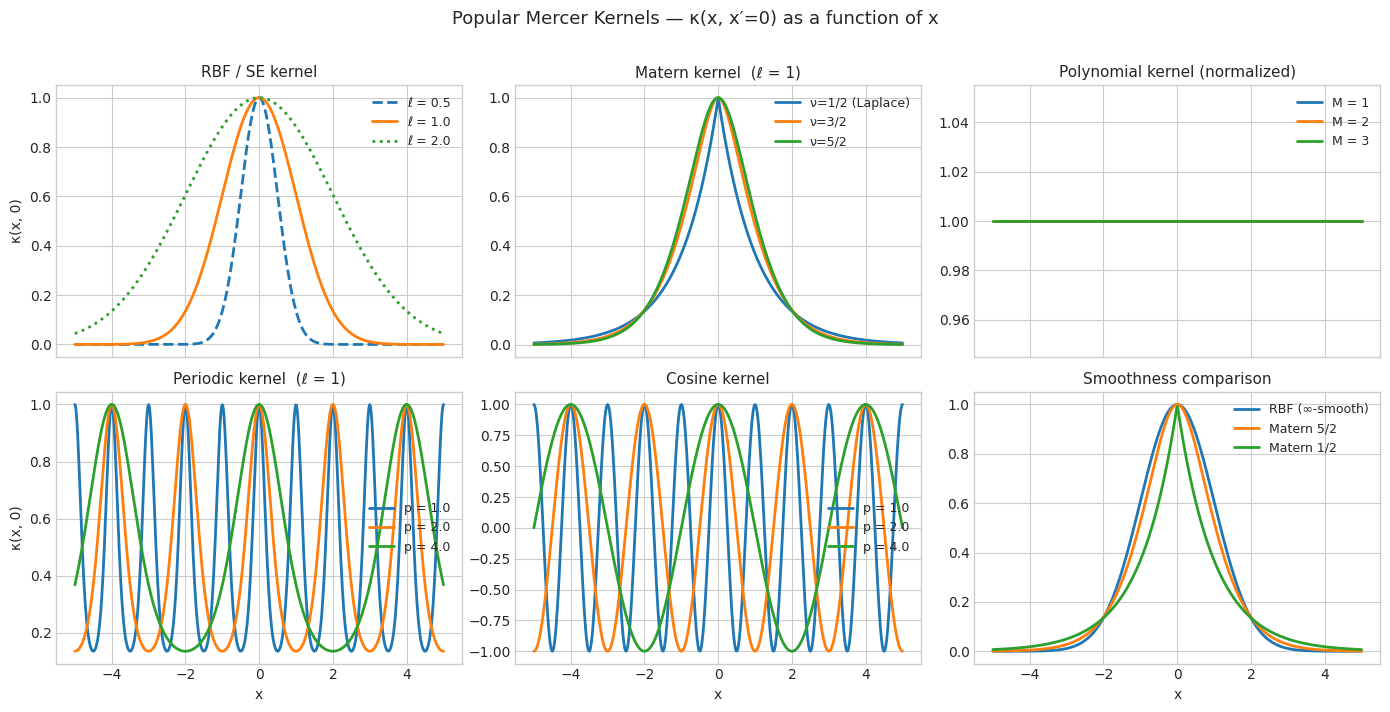

In [7]:
# Visualize kernel profiles: K(x, x'=0) as a function of x
x_grid = np.linspace(-5, 5, 500).reshape(-1, 1)
x_ref = np.array([[0.0]])

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)

# Row 1: RBF with different length scales, Matern variants
ax = axes[0, 0]
for ell, ls in [(0.5, '--'), (1.0, '-'), (2.0, ':')]:
    k = rbf_kernel(x_grid, x_ref, length_scale=ell).ravel()
    ax.plot(x_grid, k, ls, lw=2, label=f'ℓ = {ell}')
ax.set_title('RBF / SE kernel', fontsize=11)
ax.set_ylabel('κ(x, 0)')
ax.legend(fontsize=9)

ax = axes[0, 1]
for nu, label in [(0.5, 'ν=1/2 (Laplace)'), (1.5, 'ν=3/2'), (2.5, 'ν=5/2')]:
    k = matern_kernel(x_grid, x_ref, nu=nu, length_scale=1.0).ravel()
    ax.plot(x_grid, k, lw=2, label=label)
ax.set_title('Matern kernel  (ℓ = 1)', fontsize=11)
ax.legend(fontsize=9)

ax = axes[0, 2]
for deg in [1, 2, 3]:
    k = polynomial_kernel(x_grid, x_ref, degree=deg, c=1.0).ravel()
    k_norm = k / k.max()  # normalize for visualization
    ax.plot(x_grid, k_norm, lw=2, label=f'M = {deg}')
ax.set_title('Polynomial kernel (normalized)', fontsize=11)
ax.legend(fontsize=9)

# Row 2: Periodic, Cosine, comparison of smoothness
ax = axes[1, 0]
for p in [1.0, 2.0, 4.0]:
    k = periodic_kernel(x_grid, x_ref, length_scale=1.0, period=p).ravel()
    ax.plot(x_grid, k, lw=2, label=f'p = {p}')
ax.set_title('Periodic kernel  (ℓ = 1)', fontsize=11)
ax.set_xlabel('x')
ax.set_ylabel('κ(x, 0)')
ax.legend(fontsize=9)

ax = axes[1, 1]
for p in [1.0, 2.0, 4.0]:
    k = cosine_kernel(x_grid, x_ref, period=p).ravel()
    ax.plot(x_grid, k, lw=2, label=f'p = {p}')
ax.set_title('Cosine kernel', fontsize=11)
ax.set_xlabel('x')
ax.legend(fontsize=9)

# Smoothness comparison: RBF vs Matern 1/2 vs Matern 5/2
ax = axes[1, 2]
for kernel_fn, label, c in [
    (lambda X1, X2: rbf_kernel(X1, X2, 1.0), 'RBF (∞-smooth)', '#1f77b4'),
    (lambda X1, X2: matern_kernel(X1, X2, 2.5, 1.0), 'Matern 5/2', '#ff7f0e'),
    (lambda X1, X2: matern_kernel(X1, X2, 0.5, 1.0), 'Matern 1/2', '#2ca02c'),
]:
    k = kernel_fn(x_grid, x_ref).ravel()
    ax.plot(x_grid, k, lw=2, label=label, color=c)
ax.set_title('Smoothness comparison', fontsize=11)
ax.set_xlabel('x')
ax.legend(fontsize=9)

plt.suptitle('Popular Mercer Kernels — κ(x, x′=0) as a function of x', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Sampling Functions from a GP Prior

Each kernel implies a distribution over functions via $f \sim \mathcal{GP}(0, \kappa)$. To build intuition for what each kernel "believes" about function smoothness, we sample from the GP prior: draw $\mathbf{f} \sim \mathcal{N}(\mathbf{0}, \mathbf{K})$ where $K_{ij} = \kappa(x_i, x_j)$.

- **RBF** produces infinitely smooth functions
- **Matern 1/2** produces rough, jagged paths (Ornstein-Uhlenbeck process)
- **Periodic** produces repeating patterns — useful for circadian gene expression

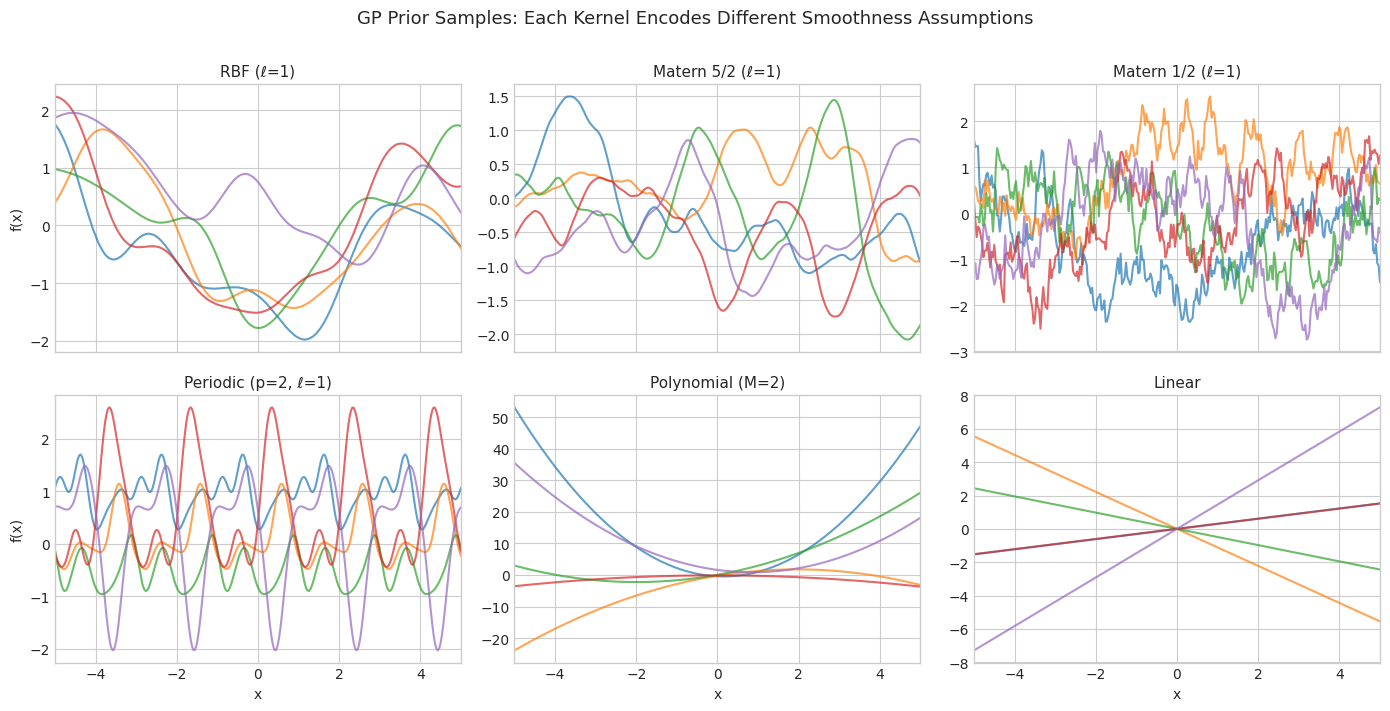

In [8]:
def sample_gp_prior(kernel_fn, x_grid, n_samples=5, jitter=1e-6):
    """Sample functions from a GP prior with the given kernel."""
    K = kernel_fn(x_grid, x_grid) + jitter * np.eye(len(x_grid))
    L = np.linalg.cholesky(K)
    z = np.random.randn(len(x_grid), n_samples)
    return L @ z


x_fine = np.linspace(-5, 5, 300).reshape(-1, 1)
n_samples = 5

kernels_to_sample = [
    ('RBF (ℓ=1)', lambda X1, X2: rbf_kernel(X1, X2, 1.0)),
    ('Matern 5/2 (ℓ=1)', lambda X1, X2: matern_kernel(X1, X2, 2.5, 1.0)),
    ('Matern 1/2 (ℓ=1)', lambda X1, X2: matern_kernel(X1, X2, 0.5, 1.0)),
    ('Periodic (p=2, ℓ=1)', lambda X1, X2: periodic_kernel(X1, X2, 1.0, 2.0)),
    ('Polynomial (M=2)', lambda X1, X2: polynomial_kernel(X1, X2, 2, 1.0)),
    ('Linear', lambda X1, X2: linear_kernel(X1, X2)),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
np.random.seed(0)

for ax, (name, kfn) in zip(axes.ravel(), kernels_to_sample):
    samples = sample_gp_prior(kfn, x_fine, n_samples)
    for s in range(n_samples):
        ax.plot(x_fine, samples[:, s], lw=1.5, alpha=0.7)
    ax.set_title(name, fontsize=11)
    ax.set_xlim(-5, 5)

axes[1, 0].set_xlabel('x')
axes[1, 1].set_xlabel('x')
axes[1, 2].set_xlabel('x')
axes[0, 0].set_ylabel('f(x)')
axes[1, 0].set_ylabel('f(x)')

plt.suptitle('GP Prior Samples: Each Kernel Encodes Different Smoothness Assumptions',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. ARD Kernel: Automatic Relevance Determination

The **ARD kernel** (Eq. 17.8) assigns a separate length scale $\ell_d$ to each input dimension:

$$\kappa(\mathbf{x}, \mathbf{x}') = \sigma^2 \exp\!\left(-\frac{1}{2}\sum_{d=1}^{D} \frac{(x_d - x_d')^2}{\ell_d^2}\right)$$

A large $\ell_d$ means dimension $d$ is **irrelevant** — differences along it are divided by a large number and thus ignored. This provides automatic feature selection: after learning $\ell_d$ from data, we discover which genes matter for phenotype prediction.

/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_9472/2433347116.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


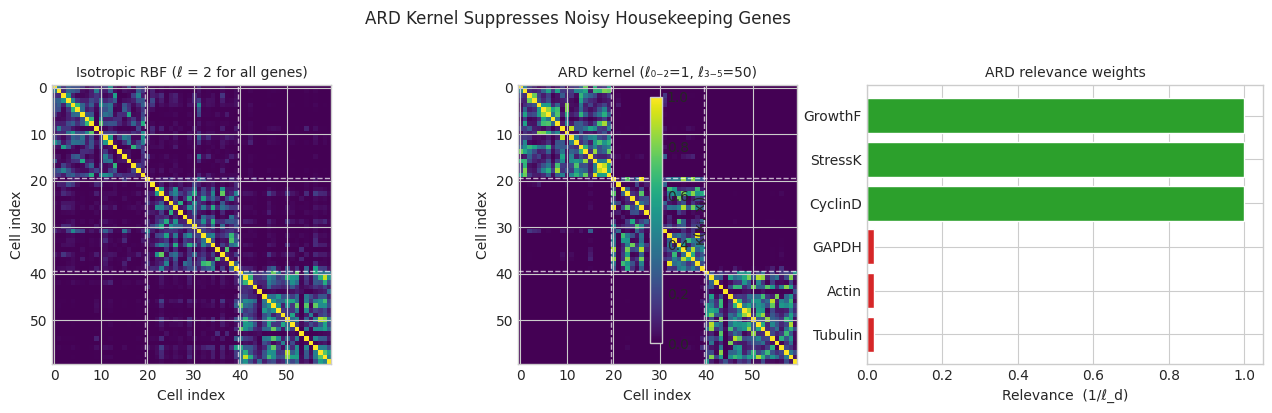

In [9]:
def ard_kernel(X1, X2, length_scales, sigma2=1.0):
    """ARD kernel (Eq. 17.8)."""
    L = np.array(length_scales)
    X1_s = X1 / L
    X2_s = X2 / L
    sq_dists = cdist(X1_s, X2_s, metric='sqeuclidean')
    return sigma2 * np.exp(-0.5 * sq_dists)


# Compare: isotropic RBF vs ARD with correct relevance
# Ground truth: genes 0-2 are discriminative (short ℓ), genes 3-5 are noise (long ℓ)
ell_isotropic = np.ones(D) * 2.0
ell_ard = np.array([1.0, 1.0, 1.0, 50.0, 50.0, 50.0])  # large ℓ for noisy dims

K_iso = ard_kernel(X_sorted, X_sorted, ell_isotropic)
K_ard = ard_kernel(X_sorted, X_sorted, ell_ard)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Isotropic
im0 = axes[0].imshow(K_iso, cmap='viridis', vmin=0, vmax=1)
axes[0].set_title('Isotropic RBF (ℓ = 2 for all genes)', fontsize=10)

# ARD
im1 = axes[1].imshow(K_ard, cmap='viridis', vmin=0, vmax=1)
axes[1].set_title('ARD kernel (ℓ₀₋₂=1, ℓ₃₋₅=50)', fontsize=10)

for ax in axes[:2]:
    ax.set_xlabel('Cell index')
    ax.set_ylabel('Cell index')
    for b in [N_per, 2 * N_per]:
        ax.axhline(b - 0.5, color='white', lw=1, ls='--', alpha=0.7)
        ax.axvline(b - 0.5, color='white', lw=1, ls='--', alpha=0.7)

# Bar chart of length scales
ax = axes[2]
bar_colors = ['#2ca02c'] * 3 + ['#d62728'] * 3
ax.barh(range(D), 1.0 / ell_ard, color=bar_colors, edgecolor='white')
ax.set_yticks(range(D))
ax.set_yticklabels(gene_names)
ax.set_xlabel('Relevance  (1/ℓ_d)')
ax.set_title('ARD relevance weights', fontsize=10)
ax.invert_yaxis()

plt.colorbar(im1, ax=axes[:2], shrink=0.8, label='κ(xᵢ, xⱼ)')
plt.suptitle('ARD Kernel Suppresses Noisy Housekeeping Genes', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 7. Combining Kernels: Addition and Multiplication

Section 17.1.2.3 shows that valid Mercer kernels can be combined:

- **Addition** $\kappa = \kappa_1 + \kappa_2$: captures the **disjunction** (OR) of properties — the combined kernel responds when *either* component detects similarity
- **Multiplication** $\kappa = \kappa_1 \times \kappa_2$: captures the **conjunction** (AND) — both components must agree for high similarity

A practical example: combine a **short-range RBF** (local gene expression similarity) with a **periodic kernel** (circadian rhythm) to model cells whose phenotypes depend on both expression level and cell-cycle phase.

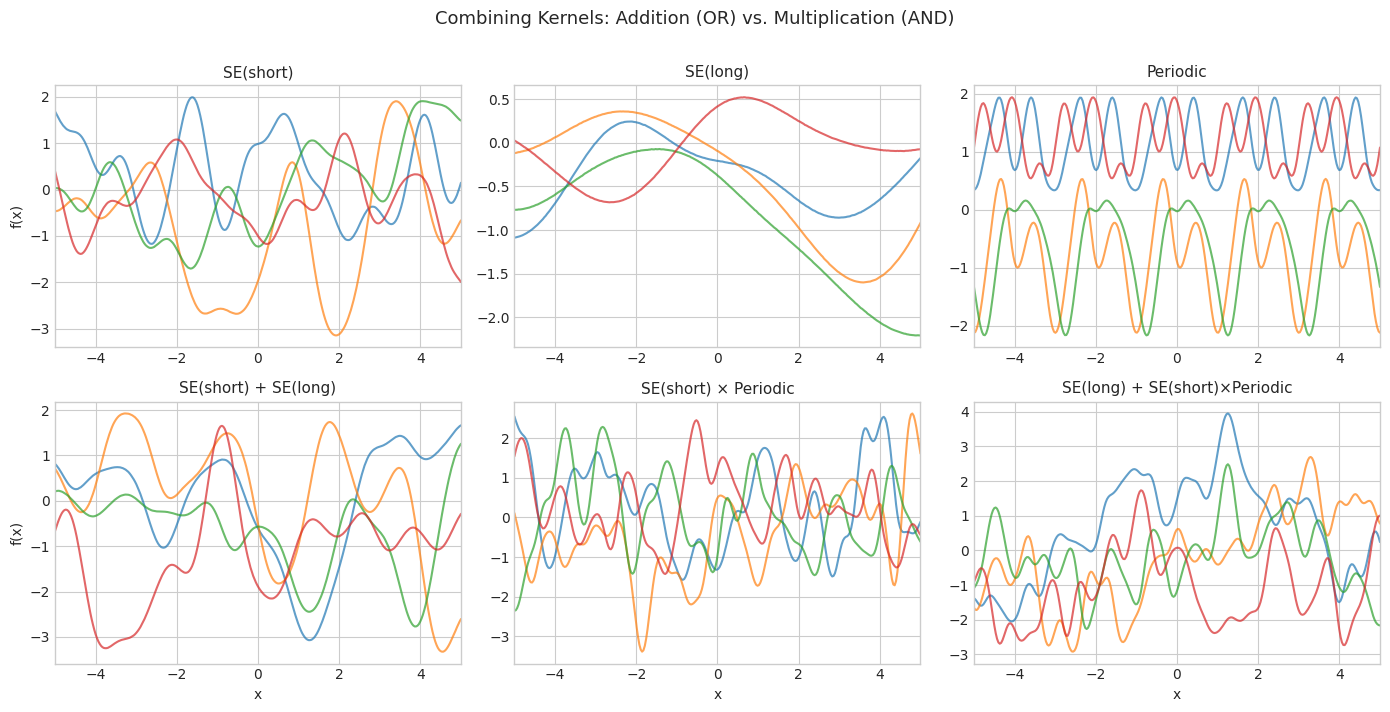

In [10]:
# Demonstrate kernel combination with GP samples in 1D
x_1d = np.linspace(-5, 5, 300).reshape(-1, 1)
np.random.seed(7)

K_se_short = rbf_kernel(x_1d, x_1d, length_scale=0.5)
K_se_long = rbf_kernel(x_1d, x_1d, length_scale=2.0)
K_per = periodic_kernel(x_1d, x_1d, length_scale=1.0, period=2.0)

combos = [
    ('SE(short)', K_se_short),
    ('SE(long)', K_se_long),
    ('Periodic', K_per),
    ('SE(short) + SE(long)', K_se_short + K_se_long),
    ('SE(short) × Periodic', K_se_short * K_per),
    ('SE(long) + SE(short)×Periodic', K_se_long + K_se_short * K_per),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
n_samp = 4

for ax, (name, K) in zip(axes.ravel(), combos):
    K_reg = K + 1e-6 * np.eye(len(x_1d))
    L = np.linalg.cholesky(K_reg)
    samples = L @ np.random.randn(len(x_1d), n_samp)
    for s in range(n_samp):
        ax.plot(x_1d, samples[:, s], lw=1.5, alpha=0.7)
    ax.set_title(name, fontsize=11)
    ax.set_xlim(-5, 5)

axes[0, 0].set_ylabel('f(x)')
axes[1, 0].set_ylabel('f(x)')
for ax in axes[1]:
    ax.set_xlabel('x')

plt.suptitle('Combining Kernels: Addition (OR) vs. Multiplication (AND)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Key observations**:
- **SE(short) + SE(long)**: slow trend with rapid local wiggles — each component contributes independently
- **SE(short) × Periodic**: locally smooth oscillations that decay away from the origin — both must agree
- **SE(long) + SE(short)×Periodic**: a smooth baseline with local periodic modulations — exactly what circadian gene expression with a slow drift looks like

## 8. Kernel Comparison on Cell Expression Data

Finally, we compare how different kernels measure similarity between our synthetic cells. We compute each kernel's Gram matrix and check whether it produces a clear block structure aligned with the true phenotypes. We quantify this using the **alignment score**: how well the kernel matrix correlates with the ideal block-diagonal label matrix.

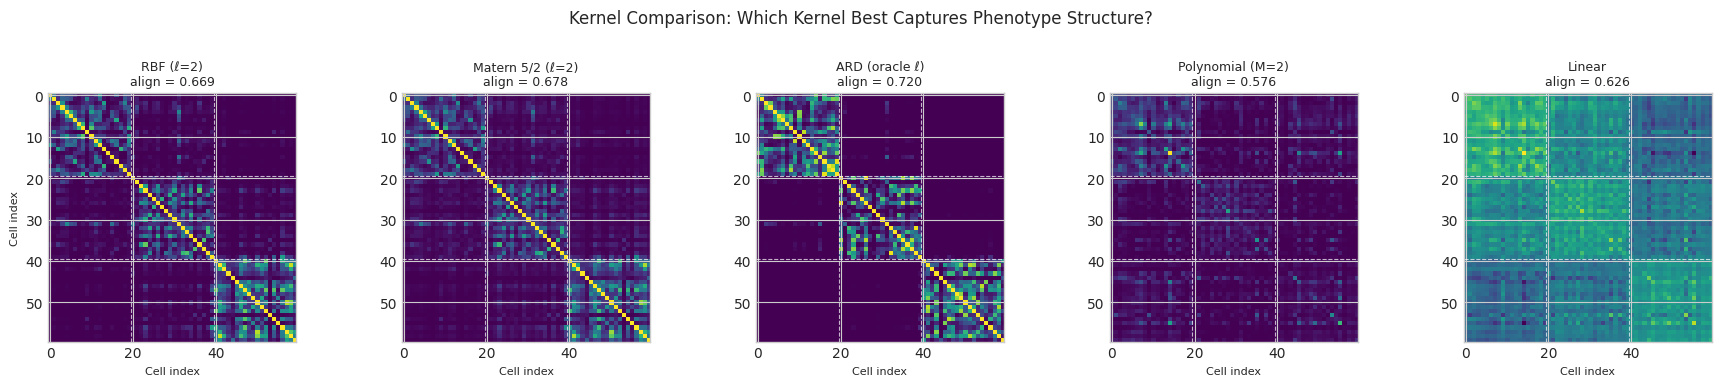


Kernel-target alignment scores (higher = better class separation):
  ARD (oracle ℓ)             0.720  ████████████████████████████
  Matern 5/2 (ℓ=2)           0.678  ███████████████████████████
  RBF (ℓ=2)                  0.669  ██████████████████████████
  Linear                     0.626  █████████████████████████
  Polynomial (M=2)           0.576  ███████████████████████


In [11]:
def kernel_alignment(K, y):
    """Kernel-target alignment: correlation between K and ideal label matrix."""
    # Ideal kernel: 1 if same class, 0 otherwise
    Y = (y[:, None] == y[None, :]).astype(float)
    # Centered alignment
    K_flat = K.ravel()
    Y_flat = Y.ravel()
    num = K_flat @ Y_flat
    denom = np.linalg.norm(K_flat) * np.linalg.norm(Y_flat)
    return num / denom


kernels_on_data = {
    'RBF (ℓ=2)': rbf_kernel(X_sorted, X_sorted, 2.0),
    'Matern 5/2 (ℓ=2)': matern_kernel(X_sorted, X_sorted, 2.5, 2.0),
    'ARD (oracle ℓ)': ard_kernel(X_sorted, X_sorted, ell_ard),
    'Polynomial (M=2)': polynomial_kernel(X_sorted, X_sorted, 2, 1.0),
    'Linear': linear_kernel(X_sorted, X_sorted),
}

# Normalize kernels to [0,1] for visualization
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

alignments = {}
for ax, (name, K) in zip(axes, kernels_on_data.items()):
    K_disp = K.copy()
    # Normalize for display
    K_disp = (K_disp - K_disp.min()) / (K_disp.max() - K_disp.min() + 1e-12)
    ax.imshow(K_disp, cmap='viridis', vmin=0, vmax=1)
    
    align = kernel_alignment(K, y_sorted)
    alignments[name] = align
    ax.set_title(f'{name}\nalign = {align:.3f}', fontsize=9)
    ax.set_xlabel('Cell index', fontsize=8)
    
    for b in [N_per, 2 * N_per]:
        ax.axhline(b - 0.5, color='white', lw=0.8, ls='--', alpha=0.7)
        ax.axvline(b - 0.5, color='white', lw=0.8, ls='--', alpha=0.7)

axes[0].set_ylabel('Cell index', fontsize=8)
plt.suptitle('Kernel Comparison: Which Kernel Best Captures Phenotype Structure?',
             fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

print('\nKernel-target alignment scores (higher = better class separation):')
for name, a in sorted(alignments.items(), key=lambda x: -x[1]):
    bar = '█' * int(a * 40)
    print(f'  {name:25s}  {a:.3f}  {bar}')

## 9. Verifying the Mercer Condition

A function is **not** a valid Mercer kernel if its Gram matrix has negative eigenvalues. Let's demonstrate this with a **non-PSD "kernel"** and contrast it with valid kernels.

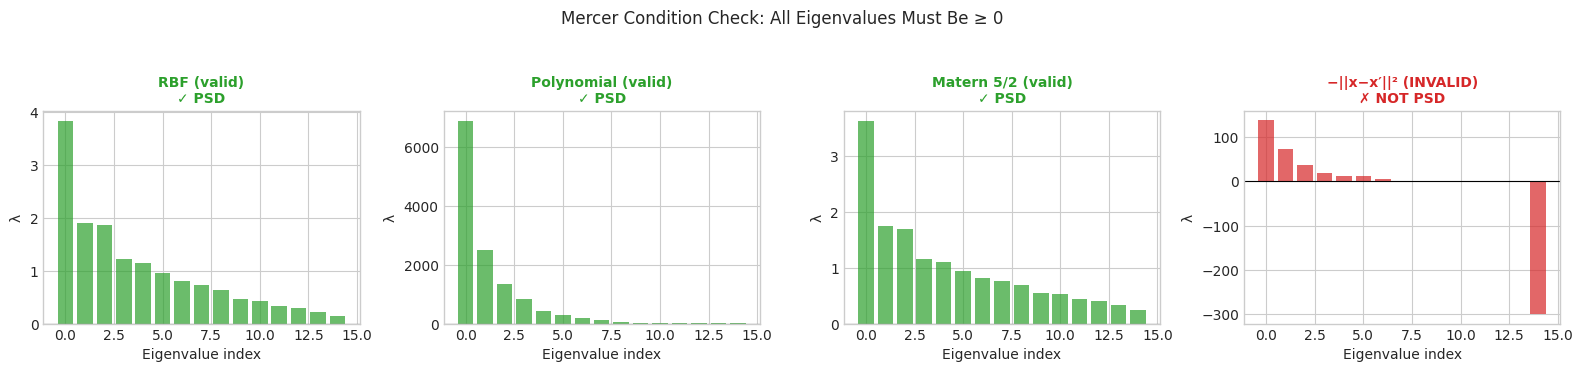

In [12]:
# A non-PSD "kernel": K(x,x') = -||x-x'||^2  (negative squared distance)
# This is NOT a Mercer kernel

X_small = X_sorted[:15]

def bad_kernel(X1, X2):
    """Not a valid Mercer kernel — produces negative eigenvalues."""
    return -cdist(X1, X2, metric='sqeuclidean')

kernels_check = {
    'RBF (valid)': rbf_kernel(X_small, X_small, 2.0),
    'Polynomial (valid)': polynomial_kernel(X_small, X_small, 2, 1.0),
    'Matern 5/2 (valid)': matern_kernel(X_small, X_small, 2.5, 2.0),
    '−||x−x′||² (INVALID)': bad_kernel(X_small, X_small),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for ax, (name, K) in zip(axes, kernels_check.items()):
    eigvals = np.linalg.eigvalsh(K)
    is_psd = np.all(eigvals >= -1e-10)
    
    color = '#2ca02c' if is_psd else '#d62728'
    ax.bar(range(len(eigvals)), np.sort(eigvals)[::-1], color=color, alpha=0.7)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{name}\n{"✓ PSD" if is_psd else "✗ NOT PSD"}', fontsize=10,
                 color=color, fontweight='bold')
    ax.set_xlabel('Eigenvalue index')
    ax.set_ylabel('λ')

plt.suptitle('Mercer Condition Check: All Eigenvalues Must Be ≥ 0', fontsize=12, y=1.05)
plt.tight_layout()
plt.show()